# C4M2 Lesson 1 Practice Lab: Using APIs

In this lab, you will practice how to access the online data using an API. You will use the `requests` module to get the data from a URL and you will perform some basic data analysis on this data.

You are interested in tracking the weather. You are building a simple app for your desktop and you want it to display the current weather at your location for you.  Here is a screenshot of what the data table would look like. 

<div style="text-align: center">
    <img src="imgsL1/page_screenshot.png" width=700>
</div>

## General instructions
- **Replace any instances of `None` with your own code**. All `None`s must be replaced.
- **Compare your results with the expected output** shown below the code.
- **Check the solution** using the expandable cell to verify your answer. If needed, you can copy the code and paste it into the cell

Happy coding!

<div style="background-color: #FAD888; padding: 10px; border-radius: 3px; box-shadow: 0 2px 4px rgba(0, 0, 0, 0.1); width:95%
">
<strong>Important note</strong>: Code blocks with None will not run properly. If you run them before completing the exercise, you will likely get an error. 

</div>

## Table of contents
- [Step 1: Import modules](#import-modules)
- [Step 2: Get the JSON](#get-the-json)
- [Step 3: Create a Pandas DataFrame](#create-pandas)
- [Step 4: Initial data analysis](#initial-data-analysis)
- [Step 5: Get live weather forecast](#live-forecast)

<a id="import-modules"></a>

## Step 1: Import modules
First, you need to import the necessary modules. In this case, you will use `requests`, `pandas` and `matplotlib`.

In [1]:
import requests
import pandas as pd
import matplotlib.pyplot as plt

<a id="get-the-json"></a>

## Step 2: Get the JSON
Use the `requests.get()` function to access the data. The URL is given below.

<div style="background-color: #C6E2FF; padding: 10px; border-radius: 3px; box-shadow: 0 2px 4px rgba(0, 0, 0, 0.1); width:95%
">
    <strong>▶▶▶ Directions</strong> 
        <ol>
            <li>Get the data from the API. </li>
            <ul>
                <li>Use <code>requests.get()</code> function to get the data.</li>
                <li>Use <code>.status_code</code> to check whether your request was successful.</li>
            </ul>
        </ol>
</div>

In [2]:
# URL of the API to get JSON data
url = "https://2eraiuh.dlai.link/api/weather"

### START CODE HERE ###

# send a GET request to the url
response = requests.get(url)

# get the status of the response for troubleshooting
status = response.status_code

### END CODE HERE ###

print(status)

200


<details open>
<summary style="background-color: #c6e2ff6c; padding: 10px; border-radius: 3px; box-shadow: 0 2px 4px rgba(0, 0, 0, 0.01); width: 95%; text-align: left; cursor: pointer; font-weight: bold;">
Expected output:</summary> 


```
200
```

</details>

<details>
<summary style="background-color: #FDBFC7; padding: 10px; border-radius: 3px; box-shadow: 0 2px 4px rgba(0, 0, 0, 0.1); width: 95%; text-align: left; cursor: pointer; font-weight: bold;">
Click here to see the solution</summary> 

<ul style="background-color: #FFF8F8; padding: 10px; border-radius: 3px; margin-top: 5px; width: 95%; box-shadow: inset 0 2px 4px rgba(0, 0, 0, 0.1);">
   
Your solution should look something like this:

```python
# send a GET request to the url
response = requests.get(url)

# get the status of the response for troubleshooting
status = response.status_code
```
</details>

You might find the above part familiar. If you have completed the previous module of this course, then you have already written the exact same piece of code to extract HTML from a webpage to later process it using Beautiful Soup. Isn't it great that sometimes you can just reuse old code?

Now use the `.json()` method to access the JSON.

<div style="background-color: #C6E2FF; padding: 10px; border-radius: 3px; box-shadow: 0 2px 4px rgba(0, 0, 0, 0.1); width:95%
">
    <strong>▶▶▶ Directions</strong> 
        <ol>
            <li>Get the JSON data from response. </li>
            <ul>
                <li>Use the <code>json()</code> method to get the JSON.</li>
            </ul>
        </ol>
</div>

In [3]:
### START CODE HERE ###

# get the JSON data from the response
data = response.json()

### END CODE HERE ###

print(type(data))

<class 'dict'>


<details open>
<summary style="background-color: #c6e2ff6c; padding: 10px; border-radius: 3px; box-shadow: 0 2px 4px rgba(0, 0, 0, 0.01); width: 95%; text-align: left; cursor: pointer; font-weight: bold;">
Expected output:</summary> 


```
<class 'dict'>
```

</details>

<details>
<summary style="background-color: #FDBFC7; padding: 10px; border-radius: 3px; box-shadow: 0 2px 4px rgba(0, 0, 0, 0.1); width: 95%; text-align: left; cursor: pointer; font-weight: bold;">
Click here to see the solution</summary> 

<ul style="background-color: #FFF8F8; padding: 10px; border-radius: 3px; margin-top: 5px; width: 95%; box-shadow: inset 0 2px 4px rgba(0, 0, 0, 0.1);">
   
Your solution should look something like this:

```python
# get the JSON data from the response
data = response.json()
```
</details>

As you saw above, the weather data is now stored in a Python dictionary. You can try printing out the whole dictionary to inspect it using `print(data)`, but since the dictionary is quite large, it is much more manageable to just print the keys of the dictionary. Use the cell below to view the keys of the `data`. Feel free to modify the code to check the full contents of the dictionary.

In [4]:
# print the keys of the JSON data
print(data.keys())

dict_keys(['data', 'success'])


<details open>
<summary style="background-color: #c6e2ff6c; padding: 10px; border-radius: 3px; box-shadow: 0 2px 4px rgba(0, 0, 0, 0.01); width: 95%; text-align: left; cursor: pointer; font-weight: bold;">
Expected output:</summary> 


```
dict_keys(['data', 'success'])
```

</details>

As you can see there are two keys: `data` and `success`. You are interested in the data, so you can select this key and see what is inside.

In [5]:
weather_data = data["data"]
weather_data.keys()

dict_keys(['current_condition', 'header', 'nearest_area', 'request', 'weather'])

<details open>
<summary style="background-color: #c6e2ff6c; padding: 10px; border-radius: 3px; box-shadow: 0 2px 4px rgba(0, 0, 0, 0.01); width: 95%; text-align: left; cursor: pointer; font-weight: bold;">
Expected output:</summary> 


```
dict_keys(['current_condition', 'header', 'nearest_area', 'request', 'weather'])
```

</details>

Inside, you find another dictionary. Nested dictionaries are quite common in APIs and sometimes you need to dig quite deep to find what you are looking for. By selecting the `weather` key, you will finally find the weather forecast data that you are looking for and you can create a DataFrame from it.

<a id="create-pandas"></a>

## Step 3: Create a Pandas DataFrame
You can access the data from the dictionary using the `weather` key and transform it into a Pandas DataFrame.

<div style="background-color: #C6E2FF; padding: 10px; border-radius: 3px; box-shadow: 0 2px 4px rgba(0, 0, 0, 0.1); width:95%
">
    <strong>▶▶▶ Directions</strong> 
        <ol>
            <li>Create a Pandas DataFrame with weather data. </li>
            <ul>
                <li>Access the weather data by using the <code>weather</code> key.</li>
                <li>Use the <code>pd.DataFrame()</code> to transform the data into a Pandas DataFrame</li>
            </ul>
        </ol>
</div>

In [6]:
### START CODE HERE ###

# get the value of the 'weather' key and transform it into a DataFrame
df = pd.DataFrame(weather_data["weather"])

### END CODE HERE ###

# display the DataFrame
df

,astronomy,avgtempC,avgtempF,date,hourly,maxtempC,maxtempF,mintempC,mintempF,sunHour,totalSnow_cm,uvIndex
0,"[{'moon_illumination': '47', 'moon_phase': 'Wa...",-4,25,2025-02-21,"[{'DewPointC': '-9', 'DewPointF': '16', 'Feels...",0,32,-6,21,11.0,0.0,1
1,"[{'moon_illumination': '38', 'moon_phase': 'Wa...",-2,29,2025-02-22,"[{'DewPointC': '-11', 'DewPointF': '13', 'Feel...",5,40,-7,19,11.0,0.0,1
2,"[{'moon_illumination': '28', 'moon_phase': 'Wa...",1,33,2025-02-23,"[{'DewPointC': '-6', 'DewPointF': '22', 'Feels...",5,42,-3,26,10.0,0.0,1


<details open>
<summary style="background-color: #c6e2ff6c; padding: 10px; border-radius: 3px; box-shadow: 0 2px 4px rgba(0, 0, 0, 0.01); width: 95%; text-align: left; cursor: pointer; font-weight: bold;">
Expected output:</summary> 


<img src="imgsL1/output_step3.png">

</details>

<details>
<summary style="background-color: #FDBFC7; padding: 10px; border-radius: 3px; box-shadow: 0 2px 4px rgba(0, 0, 0, 0.1); width: 95%; text-align: left; cursor: pointer; font-weight: bold;">
Click here to see the solution</summary> 

<ul style="background-color: #FFF8F8; padding: 10px; border-radius: 3px; margin-top: 5px; width: 95%; box-shadow: inset 0 2px 4px rgba(0, 0, 0, 0.1);">
   
Your solution should look something like this:

```python
# get the value of the 'weather' key and transform it into a DataFrame
df = pd.DataFrame(weather_data["weather"])
```
</details>

As you can see there are only three rows in the DataFrame, each one representing the weather for a certain date, meaning this is a three day weather forecast. You can see simple columns that represent for example temperatures, hours of sun and snow depth, but you have also more complex columns like `astronomy` and `hourly`, which look like they contain a list of dictionaries. Could it be that each of these cells contains its own DataFrame?

<a id="initial-data-analysis"></a>

## Step 4: Initial data analysis

Let's start with analysis of the simple columns and return to the above problem later. In order to analyze the data, you need to first cast the values to the appropriate types and then you can plot the daily temperatures.

<div style="background-color: #C6E2FF; padding: 10px; border-radius: 3px; box-shadow: 0 2px 4px rgba(0, 0, 0, 0.1); width:95%
">
    <strong>▶▶▶ Directions</strong> 
        <ol>
            <li>Cast the numeric and date columns and create a datetime index. </li>
            <ul>
                <li>Store the names of numeric columns in a list.</li>
                <li>Cast the <code>numeric columns</code> to float.</li>
                <li>Cast the <code>"date"</code> column to datetime.</li>
                <li>Set the <code>"date"</code> column as the index of the DataFrame.</li>
            </ul>
        </ol>
</div>

In [8]:
# Store the names of numeric columns in a list
numeric_columns = ["mintempC", "maxtempC", "totalSnow_cm", "sunHour", "mintempF", "maxtempF", "uvIndex", "avgtempF", "avgtempC"]

### START CODE HERE ###

# Cast the numeric columns to float
df[numeric_columns] = df[numeric_columns].astype(float)

# Cast the date column to datetime
df["date"] = pd.to_datetime(df["date"])

### END CODE HERE ###
 
# Set the date column as the index of the DataFrame
df.set_index(df["date"], inplace=True)

<details>
<summary style="background-color: #FDBFC7; padding: 10px; border-radius: 3px; box-shadow: 0 2px 4px rgba(0, 0, 0, 0.1); width: 95%; text-align: left; cursor: pointer; font-weight: bold;">
Click here to see the solution</summary> 

<ul style="background-color: #FFF8F8; padding: 10px; border-radius: 3px; margin-top: 5px; width: 95%; box-shadow: inset 0 2px 4px rgba(0, 0, 0, 0.1);">
   
Your solution should look something like this:

```python
# Store the names of numeric columns in a list
numeric_columns = ["mintempC", "maxtempC", "totalSnow_cm", "sunHour", "mintempF", "maxtempF", "uvIndex", "avgtempF", "avgtempC"]

# Cast the numeric columns to float
df[numeric_columns] = df[numeric_columns].astype(float)

# Cast the date column to datetime
df["date"] = pd.to_datetime(df["date"])

# Set the date column as the index of the DataFrame
df.set_index("date", inplace=True)
```
</details>

Now that you have your data prepared, you can plot the daily temperatures for the three days forecast. You're not expected to know this code. Remember you can always check with an LLM.

<div style="background-color: #C6E2FF; padding: 10px; border-radius: 3px; box-shadow: 0 2px 4px rgba(0, 0, 0, 0.1); width:95%
">
    <strong>▶▶▶ Directions</strong> 
        <ol>
            <li>Plot the forecasted maximum and minimum daily temperature. </li>
            <ul>
                <li>Plot the minimum temperature in celsius in blue and the maximum in red.</li>
                <li>Add the title and x and y labels.</li>
            </ul>
        </ol>
</div>

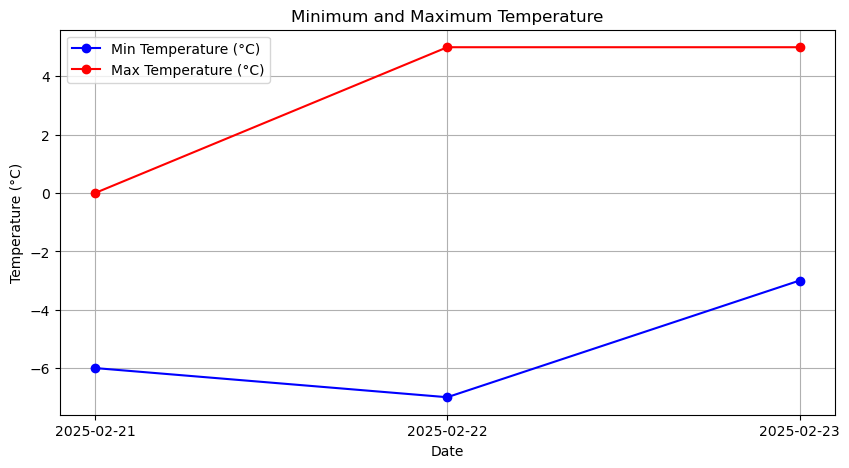

In [9]:
### START CODE HERE ###

# Plot the maximum and minimum daily temperature
plt.figure(figsize=(10, 5))
plt.plot(df.index, df["mintempC"], label="Min Temperature (°C)", marker="o", color="blue")
plt.plot(df.index, df["maxtempC"], label="Max Temperature (°C)", marker="o", color="red")

# Add the title and labels
plt.title("Minimum and Maximum Temperature")
plt.xlabel("Date")
plt.ylabel("Temperature (°C)")

### END CODE HERE ###

# Set the ticks to be the date
plt.xticks(df.index, df.index.strftime("%Y-%m-%d"))

# Show the grid and the legend
plt.grid(True)
plt.legend()

# Display the plot
plt.show()

<details open>
<summary style="background-color: #c6e2ff6c; padding: 10px; border-radius: 3px; box-shadow: 0 2px 4px rgba(0, 0, 0, 0.01); width: 95%; text-align: left; cursor: pointer; font-weight: bold;">
Expected output:</summary> 

<img src="imgsL1/daily_forecast.png" width="350">

</details>

<details>
<summary style="background-color: #FDBFC7; padding: 10px; border-radius: 3px; box-shadow: 0 2px 4px rgba(0, 0, 0, 0.1); width: 95%; text-align: left; cursor: pointer; font-weight: bold;">
Click here to see the solution</summary> 

<ul style="background-color: #FFF8F8; padding: 10px; border-radius: 3px; margin-top: 5px; width: 95%; box-shadow: inset 0 2px 4px rgba(0, 0, 0, 0.1);">
   
Your solution should look something like this:

```python
# Plot the maximum and minimum daily temperature
plt.figure(figsize=(10, 5))
plt.plot(df.index, df["mintempC"], label="Min Temperature (°C)", marker="o", color="blue")
plt.plot(df.index, df["maxtempC"], label="Max Temperature (°C)", marker="o", color="red")

# Add the title and labels
plt.title("Minimum and Maximum Temperature")
plt.xlabel("Date")
plt.ylabel("Temperature (°C)")
```
</details>

In this lab you have worked with weather data available from an API. You have seen that the formats of the data are not always very simple as they may contain DataFrames within DataFrames and thus require extra processing.

<a id="live-forecast"></a>

## Step 5: Get live weather forecast

This weather data you have been working with actually came from [wttr.in](https://wttr.in). You can run the cell below to get the latest forecast—just update the `city` to one you like. It will refresh the `df` DataFrame, so you can go back and rerun your charts with fresh data. Since it’s a live API, results might change a bit. The part after the "?" in the URL sets the output format using query parameters. You can find more options in their [GitHub repository](https://github.com/chubin/wttr.in).

In [10]:
# URL of the API to get JSON data
city = "Sydney"
url_wttr = f"http://wttr.in/{city}?format=j1"

# send a GET request to the url
response_wttr = requests.get(url_wttr)

# get the status of the response for troubleshooting
weather_data = response.json()
weather_data = weather_data["data"]

# get the value of the 'weather' key and transform it into a DataFrame
df = pd.DataFrame(weather_data["weather"])

# print the first few rows
df.head()

,astronomy,avgtempC,avgtempF,date,hourly,maxtempC,maxtempF,mintempC,mintempF,sunHour,totalSnow_cm,uvIndex
0,"[{'moon_illumination': '47', 'moon_phase': 'Wa...",-4,25,2025-02-21,"[{'DewPointC': '-9', 'DewPointF': '16', 'Feels...",0,32,-6,21,11.0,0.0,1
1,"[{'moon_illumination': '38', 'moon_phase': 'Wa...",-2,29,2025-02-22,"[{'DewPointC': '-11', 'DewPointF': '13', 'Feel...",5,40,-7,19,11.0,0.0,1
2,"[{'moon_illumination': '28', 'moon_phase': 'Wa...",1,33,2025-02-23,"[{'DewPointC': '-6', 'DewPointF': '22', 'Feels...",5,42,-3,26,10.0,0.0,1


Now try what happens if you remove the parameters after the question mark! In this case the API does not return a JSON but plain text. if you try to access `.json()` in this case you will get an error. Instead you can use `.text`. Run the cell below to print it out to see what the API returns when no additional parameters are set.

In [11]:
# URL of the API to get JSON data
city = "Sydney"
url_wttr_2 = f"http://wttr.in/{city}"

# send a GET request to the url
response_wttr_2 = requests.get(url_wttr_2)

print(response_wttr_2.text)

Weather report: Sydney

   _`/"".-.     Patchy light drizzle
    ,\_(   ).   18 °C
     /(___(__)  ↑ 20 km/h
       ‘ ‘ ‘ ‘  10 km
      ‘ ‘ ‘ ‘   0.3 mm
                                                       ┌─────────────┐
┌──────────────────────────────┬───────────────────────┤  Sun 14 Jun ├───────────────────────┬──────────────────────────────┐
│            Morning           │             Noon      └──────┬──────┘     Evening           │             Night            │
├──────────────────────────────┼──────────────────────────────┼──────────────────────────────┼──────────────────────────────┤
│    \  /       Partly Cloudy  │  _`/"".-.     Patchy rain ne…│      .-.      Light drizzle  │  _`/"".-.     Light rain sho…│
│  _ /"".-.     18 °C          │   ,\_(   ).   20 °C          │     (   ).    17 °C          │   ,\_(   ).   17 °C          │
│    \_(   ).   ↗ 11-15 km/h   │    /(___(__)  ↑ 19-23 km/h   │    (___(__)   ↖ 25-36 km/h   │    /(___(__)  ↖ 22-32 km/h   │
│    /(___(__)  10 

Aren't APIs fun? It turns out they can return much more than just JSON data.

Congratulations for making it until the end of this lab. You have used your first API to get the weather data and plot it. You can modify this code and build on top of it to create your own weather forecasting app. Hope you enjoyed it! 